In [1]:
# Parameters
run_id = "ff65ae5c-f636-4122-9894-971278e5e4d2"
artifacts_dir = "/home/adnoman/projects/aml_gan/AMLend2end/artifacts/runs/ff65ae5c-f636-4122-9894-971278e5e4d2"
sample_size = None
epochs = None
threshold = None


# AML Analytical Dashboard

Interactive dashboard with multiple analysis views:
- **Tab 1**: Executive Summary & KPIs
- **Tab 2**: Loss vs Savings Analysis
- **Tab 3**: Risk-Weighted Network Visualization
- **Tab 4**: Transaction Deep Dive
- **Tab 5**: Node Risk Profiles

In [2]:
# Setup and imports
import os
import json
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from matplotlib.lines import Line2D
from matplotlib.colors import LinearSegmentedColormap, Normalize
from matplotlib.cm import ScalarMappable
import networkx as nx
from tensorflow import keras
import warnings
warnings.filterwarnings('ignore')

# Try to import ipywidgets for interactive tabs
try:
    import ipywidgets as widgets
    from IPython.display import display, HTML, clear_output
    HAS_WIDGETS = True
except ImportError:
    HAS_WIDGETS = False
    from IPython.display import display, HTML

# Define paths
BASE_PATH = os.path.dirname(os.path.abspath("__file__"))
TRAINING_DATA_PATH = os.path.join(BASE_PATH, "training_data")
OUTPUT_PATH = os.path.join(BASE_PATH, "output")
MODELS_PATH = os.path.join(BASE_PATH, "models")

# Dashboard styling
plt.style.use('default')
plt.rcParams['figure.figsize'] = [14, 8]
plt.rcParams['figure.dpi'] = 100
plt.rcParams['axes.titlesize'] = 14
plt.rcParams['axes.labelsize'] = 12

# Demo configuration - Assumption rates for loss/savings calculations
DEMO_CONFIG = {
    'avg_loss_per_undetected_aml': 0.15,  # 15% of transaction value lost if AML goes undetected
    'investigation_cost_per_alert': 500,   # Cost to investigate each alert
    'false_positive_cost': 200,            # Cost of false positive (customer friction)
    'regulatory_fine_multiplier': 3.0,     # Fine multiplier for undetected AML
    'recovery_rate_detected': 0.70,        # 70% recovery rate for detected AML
    'currency': 'USD'
}

print("Dashboard initialized!")
print(f"Interactive widgets available: {HAS_WIDGETS}")

2026-02-02 16:54:06.525996: I tensorflow/core/util/port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
2026-02-02 16:54:06.559817: I tensorflow/core/platform/cpu_feature_guard.cc:210] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 AVX_VNNI FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.


2026-02-02 16:54:07.426866: I tensorflow/core/util/port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.


Dashboard initialized!
Interactive widgets available: True


In [3]:
# Load all data
print("Loading data...")

# Load edges (transactions)
edges_df = pd.read_csv(os.path.join(TRAINING_DATA_PATH, "edges_td.csv"))
print(f"  Transactions: {len(edges_df):,}")

# Load nodes (parties)
nodes_df = pd.read_csv(os.path.join(TRAINING_DATA_PATH, "node_td.csv"))
print(f"  Nodes: {len(nodes_df):,}")

# Load node embeddings
node_embeddings = pd.read_parquet(os.path.join(OUTPUT_PATH, "node_embeddings_fg.parquet"))
print(f"  Node embeddings: {len(node_embeddings):,}")

# Load the trained model
model_dirs = [d for d in os.listdir(MODELS_PATH) if d.startswith('gan_anomaly_')]
latest_model_dir = os.path.join(MODELS_PATH, sorted(model_dirs)[-1])
model = keras.models.load_model(os.path.join(latest_model_dir, "anomaly_detector.keras"))
threshold = np.load(os.path.join(latest_model_dir, "threshold.npy"))
print(f"  Model loaded: {latest_model_dir.split('/')[-1]}")

# Compute anomaly scores
emb_cols = [c for c in node_embeddings.columns if c.startswith('emb_')]
all_embeddings = node_embeddings[emb_cols].values
reconstructed = model.predict(all_embeddings, verbose=0)
anomaly_scores = np.mean(np.square(all_embeddings - reconstructed), axis=1)

node_embeddings['anomaly_score'] = anomaly_scores
node_embeddings['is_anomaly'] = anomaly_scores > threshold

# Normalize anomaly scores to 0-1 for risk levels
score_min, score_max = anomaly_scores.min(), anomaly_scores.max()
node_embeddings['risk_score'] = (anomaly_scores - score_min) / (score_max - score_min)

print(f"\nData loading complete!")

Loading data...
  Transactions: 438,386
  Nodes: 7,347
  Node embeddings: 7,347


I0000 00:00:1770033248.128795  119590 gpu_device.cc:2020] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 9511 MB memory:  -> device: 0, name: NVIDIA GeForce RTX 4080 Laptop GPU, pci bus id: 0000:01:00.0, compute capability: 8.9


  Model loaded: gan_anomaly_5f5ae592


2026-02-02 16:54:08.920904: I external/local_xla/xla/service/service.cc:163] XLA service 0x7834880031a0 initialized for platform CUDA (this does not guarantee that XLA will be used). Devices:
2026-02-02 16:54:08.920931: I external/local_xla/xla/service/service.cc:171]   StreamExecutor device (0): NVIDIA GeForce RTX 4080 Laptop GPU, Compute Capability 8.9
2026-02-02 16:54:08.925147: I tensorflow/compiler/mlir/tensorflow/utils/dump_mlir_util.cc:269] disabling MLIR crash reproducer, set env var `MLIR_CRASH_REPRODUCER_DIRECTORY` to enable.
2026-02-02 16:54:08.945174: I external/local_xla/xla/stream_executor/cuda/cuda_dnn.cc:473] Loaded cuDNN version 91801


I0000 00:00:1770033249.351375  119797 device_compiler.h:196] Compiled cluster using XLA!  This line is logged at most once for the lifetime of the process.



Data loading complete!


In [4]:
# Prepare transaction-level risk data
# Map node risk to edges
node_risk_dict = node_embeddings.set_index('id')['risk_score'].to_dict()
node_anomaly_dict = node_embeddings.set_index('id')['is_anomaly'].to_dict()

# Calculate edge risk (max of source and target risk)
edges_df['source_risk'] = edges_df['source'].map(node_risk_dict).fillna(0)
edges_df['target_risk'] = edges_df['target'].map(node_risk_dict).fillna(0)
edges_df['edge_risk'] = edges_df[['source_risk', 'target_risk']].max(axis=1)
edges_df['source_anomaly'] = edges_df['source'].map(node_anomaly_dict).fillna(False)
edges_df['target_anomaly'] = edges_df['target'].map(node_anomaly_dict).fillna(False)
edges_df['is_suspicious'] = edges_df['source_anomaly'] | edges_df['target_anomaly']

# Calculate money flow per node
outgoing = edges_df.groupby('source').agg({'base_amt': 'sum', 'tran_id': 'count'}).rename(
    columns={'base_amt': 'outgoing_amt', 'tran_id': 'outgoing_count'})
incoming = edges_df.groupby('target').agg({'base_amt': 'sum', 'tran_id': 'count'}).rename(
    columns={'base_amt': 'incoming_amt', 'tran_id': 'incoming_count'})

node_money = node_embeddings[['id', 'anomaly_score', 'is_anomaly', 'risk_score']].copy()
if 'is_sar' in node_embeddings.columns:
    node_money['is_sar'] = node_embeddings['is_sar']
node_money = node_money.merge(outgoing, left_on='id', right_index=True, how='left')
node_money = node_money.merge(incoming, left_on='id', right_index=True, how='left')
node_money = node_money.fillna(0)
node_money['total_volume'] = node_money['outgoing_amt'] + node_money['incoming_amt']
node_money['total_transactions'] = node_money['outgoing_count'] + node_money['incoming_count']

print("Edge risk and money flow data prepared!")

Edge risk and money flow data prepared!


---
# TAB 1: Executive Summary & KPIs
---

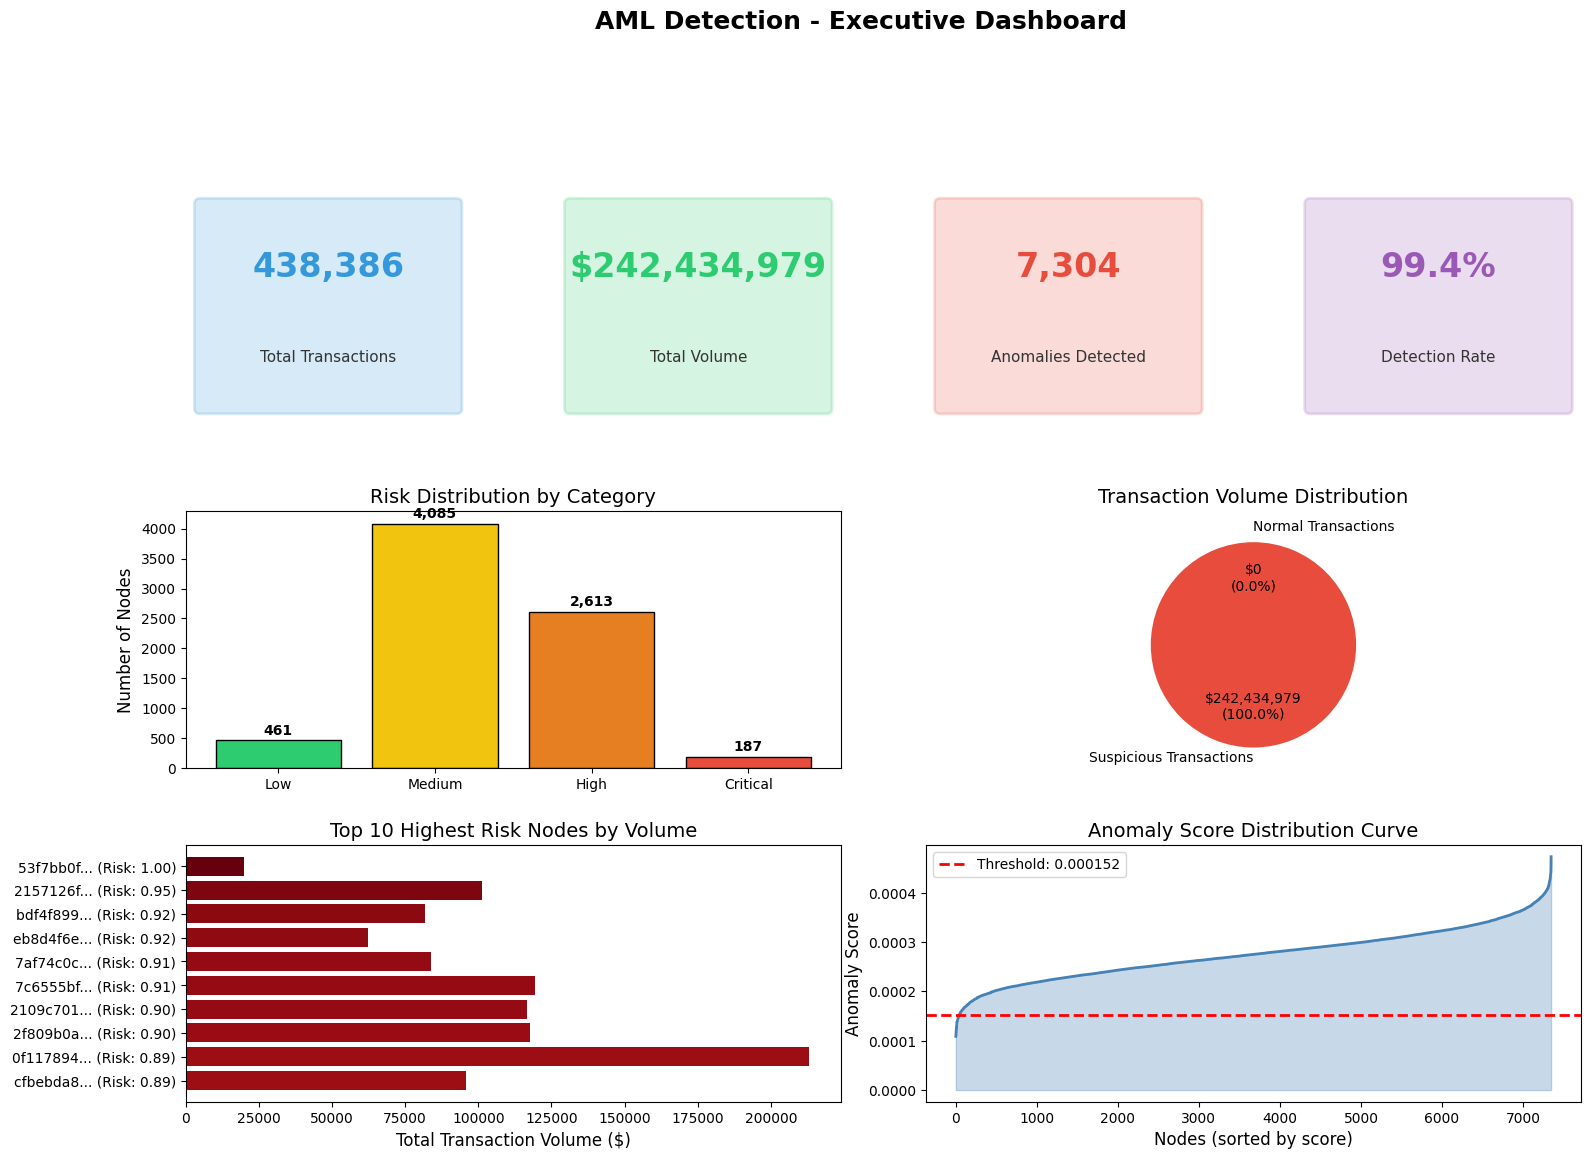

In [5]:
# Executive Summary Dashboard
def render_executive_summary():
    fig = plt.figure(figsize=(18, 12))
    
    # Create grid for KPI cards and charts
    gs = fig.add_gridspec(3, 4, hspace=0.3, wspace=0.3)
    
    # ========== KPI CARDS (Row 1) ==========
    kpi_data = [
        ('Total Transactions', f"{len(edges_df):,}", '#3498db'),
        ('Total Volume', f"${edges_df['base_amt'].sum():,.0f}", '#2ecc71'),
        ('Anomalies Detected', f"{node_embeddings['is_anomaly'].sum():,}", '#e74c3c'),
        ('Detection Rate', f"{100*node_embeddings['is_anomaly'].mean():.1f}%", '#9b59b6'),
    ]
    
    for i, (title, value, color) in enumerate(kpi_data):
        ax = fig.add_subplot(gs[0, i])
        ax.set_xlim(0, 1)
        ax.set_ylim(0, 1)
        
        # KPI card background
        rect = mpatches.FancyBboxPatch((0.05, 0.1), 0.9, 0.8, boxstyle="round,pad=0.02",
                                        facecolor=color, alpha=0.2, edgecolor=color, linewidth=2)
        ax.add_patch(rect)
        
        ax.text(0.5, 0.65, value, ha='center', va='center', fontsize=24, fontweight='bold', color=color)
        ax.text(0.5, 0.3, title, ha='center', va='center', fontsize=11, color='#333')
        ax.axis('off')
    
    # ========== Risk Distribution (Row 2, Left) ==========
    ax1 = fig.add_subplot(gs[1, :2])
    risk_bins = [0, 0.25, 0.5, 0.75, 1.0]
    risk_labels = ['Low', 'Medium', 'High', 'Critical']
    risk_colors = ['#2ecc71', '#f1c40f', '#e67e22', '#e74c3c']
    
    risk_counts = pd.cut(node_embeddings['risk_score'], bins=risk_bins, labels=risk_labels).value_counts()
    bars = ax1.bar(risk_labels, [risk_counts.get(l, 0) for l in risk_labels], color=risk_colors, edgecolor='black')
    ax1.set_ylabel('Number of Nodes')
    ax1.set_title('Risk Distribution by Category')
    
    for bar, count in zip(bars, [risk_counts.get(l, 0) for l in risk_labels]):
        ax1.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 50, f'{count:,}', 
                 ha='center', va='bottom', fontsize=10, fontweight='bold')
    
    # ========== Transaction Volume by Risk (Row 2, Right) ==========
    ax2 = fig.add_subplot(gs[1, 2:])
    suspicious_vol = edges_df[edges_df['is_suspicious']]['base_amt'].sum()
    normal_vol = edges_df[~edges_df['is_suspicious']]['base_amt'].sum()
    
    wedges, texts, autotexts = ax2.pie(
        [normal_vol, suspicious_vol], 
        labels=['Normal Transactions', 'Suspicious Transactions'],
        colors=['#3498db', '#e74c3c'],
        autopct=lambda p: f'${p*edges_df["base_amt"].sum()/100:,.0f}\n({p:.1f}%)',
        explode=(0, 0.05),
        startangle=90
    )
    ax2.set_title('Transaction Volume Distribution')
    
    # ========== Top Risk Nodes (Row 3, Left) ==========
    ax3 = fig.add_subplot(gs[2, :2])
    top_risk = node_money.nlargest(10, 'risk_score')
    colors = plt.cm.Reds(top_risk['risk_score'])
    bars = ax3.barh(range(len(top_risk)), top_risk['total_volume'], color=colors)
    ax3.set_yticks(range(len(top_risk)))
    ax3.set_yticklabels([f"{id[:8]}... (Risk: {r:.2f})" for id, r in zip(top_risk['id'], top_risk['risk_score'])])
    ax3.set_xlabel('Total Transaction Volume ($)')
    ax3.set_title('Top 10 Highest Risk Nodes by Volume')
    ax3.invert_yaxis()
    
    # ========== Anomaly Score Trend (Row 3, Right) ==========
    ax4 = fig.add_subplot(gs[2, 2:])
    sorted_scores = np.sort(node_embeddings['anomaly_score'])
    ax4.fill_between(range(len(sorted_scores)), sorted_scores, alpha=0.3, color='steelblue')
    ax4.plot(sorted_scores, color='steelblue', linewidth=2)
    ax4.axhline(y=threshold, color='red', linestyle='--', linewidth=2, label=f'Threshold: {threshold:.6f}')
    ax4.set_xlabel('Nodes (sorted by score)')
    ax4.set_ylabel('Anomaly Score')
    ax4.set_title('Anomaly Score Distribution Curve')
    ax4.legend()
    
    plt.suptitle('AML Detection - Executive Dashboard', fontsize=18, fontweight='bold', y=1.02)
    plt.tight_layout()
    plt.savefig(os.path.join(OUTPUT_PATH, 'dashboard_executive.png'), dpi=150, bbox_inches='tight')
    plt.show()

render_executive_summary()

---
# TAB 2: Loss vs Savings Analysis
---

In [6]:
# Loss vs Savings Calculator
def calculate_loss_savings():
    """Calculate potential losses avoided and operational costs"""
    
    # Suspicious transaction value
    suspicious_txn_value = edges_df[edges_df['is_suspicious']]['base_amt'].sum()
    normal_txn_value = edges_df[~edges_df['is_suspicious']]['base_amt'].sum()
    
    # Number of alerts
    n_anomalies = node_embeddings['is_anomaly'].sum()
    n_normal = len(node_embeddings) - n_anomalies
    
    # Estimate true positives and false positives (using SAR labels if available)
    if 'is_sar' in node_embeddings.columns:
        true_positives = ((node_embeddings['is_sar'] == 1) & (node_embeddings['is_anomaly'])).sum()
        false_positives = ((node_embeddings['is_sar'] == 0) & (node_embeddings['is_anomaly'])).sum()
        false_negatives = ((node_embeddings['is_sar'] == 1) & (~node_embeddings['is_anomaly'])).sum()
        true_negatives = ((node_embeddings['is_sar'] == 0) & (~node_embeddings['is_anomaly'])).sum()
    else:
        # Estimate based on industry averages (assume 10% of anomalies are true AML)
        est_true_positive_rate = 0.10
        true_positives = int(n_anomalies * est_true_positive_rate)
        false_positives = n_anomalies - true_positives
        false_negatives = int(n_normal * 0.01)  # Assume 1% of normals are missed AML
        true_negatives = n_normal - false_negatives
    
    # Financial calculations
    cfg = DEMO_CONFIG
    
    # Potential loss from detected AML (avoided)
    avg_suspicious_txn = suspicious_txn_value / max(n_anomalies, 1)
    potential_loss_detected = true_positives * avg_suspicious_txn * cfg['avg_loss_per_undetected_aml']
    recovered_amount = potential_loss_detected * cfg['recovery_rate_detected']
    
    # Potential loss from undetected AML (not avoided)
    avg_normal_txn = normal_txn_value / max(n_normal, 1)
    potential_loss_undetected = false_negatives * avg_normal_txn * cfg['avg_loss_per_undetected_aml']
    regulatory_fine_risk = potential_loss_undetected * cfg['regulatory_fine_multiplier']
    
    # Operational costs
    investigation_cost = n_anomalies * cfg['investigation_cost_per_alert']
    false_positive_cost = false_positives * cfg['false_positive_cost']
    total_operational_cost = investigation_cost + false_positive_cost
    
    # Net savings
    gross_savings = recovered_amount
    net_savings = gross_savings - total_operational_cost
    
    return {
        'true_positives': true_positives,
        'false_positives': false_positives,
        'false_negatives': false_negatives,
        'true_negatives': true_negatives,
        'suspicious_txn_value': suspicious_txn_value,
        'potential_loss_detected': potential_loss_detected,
        'recovered_amount': recovered_amount,
        'potential_loss_undetected': potential_loss_undetected,
        'regulatory_fine_risk': regulatory_fine_risk,
        'investigation_cost': investigation_cost,
        'false_positive_cost': false_positive_cost,
        'total_operational_cost': total_operational_cost,
        'gross_savings': gross_savings,
        'net_savings': net_savings
    }

loss_savings = calculate_loss_savings()
print("Loss/Savings analysis calculated!")

Loss/Savings analysis calculated!


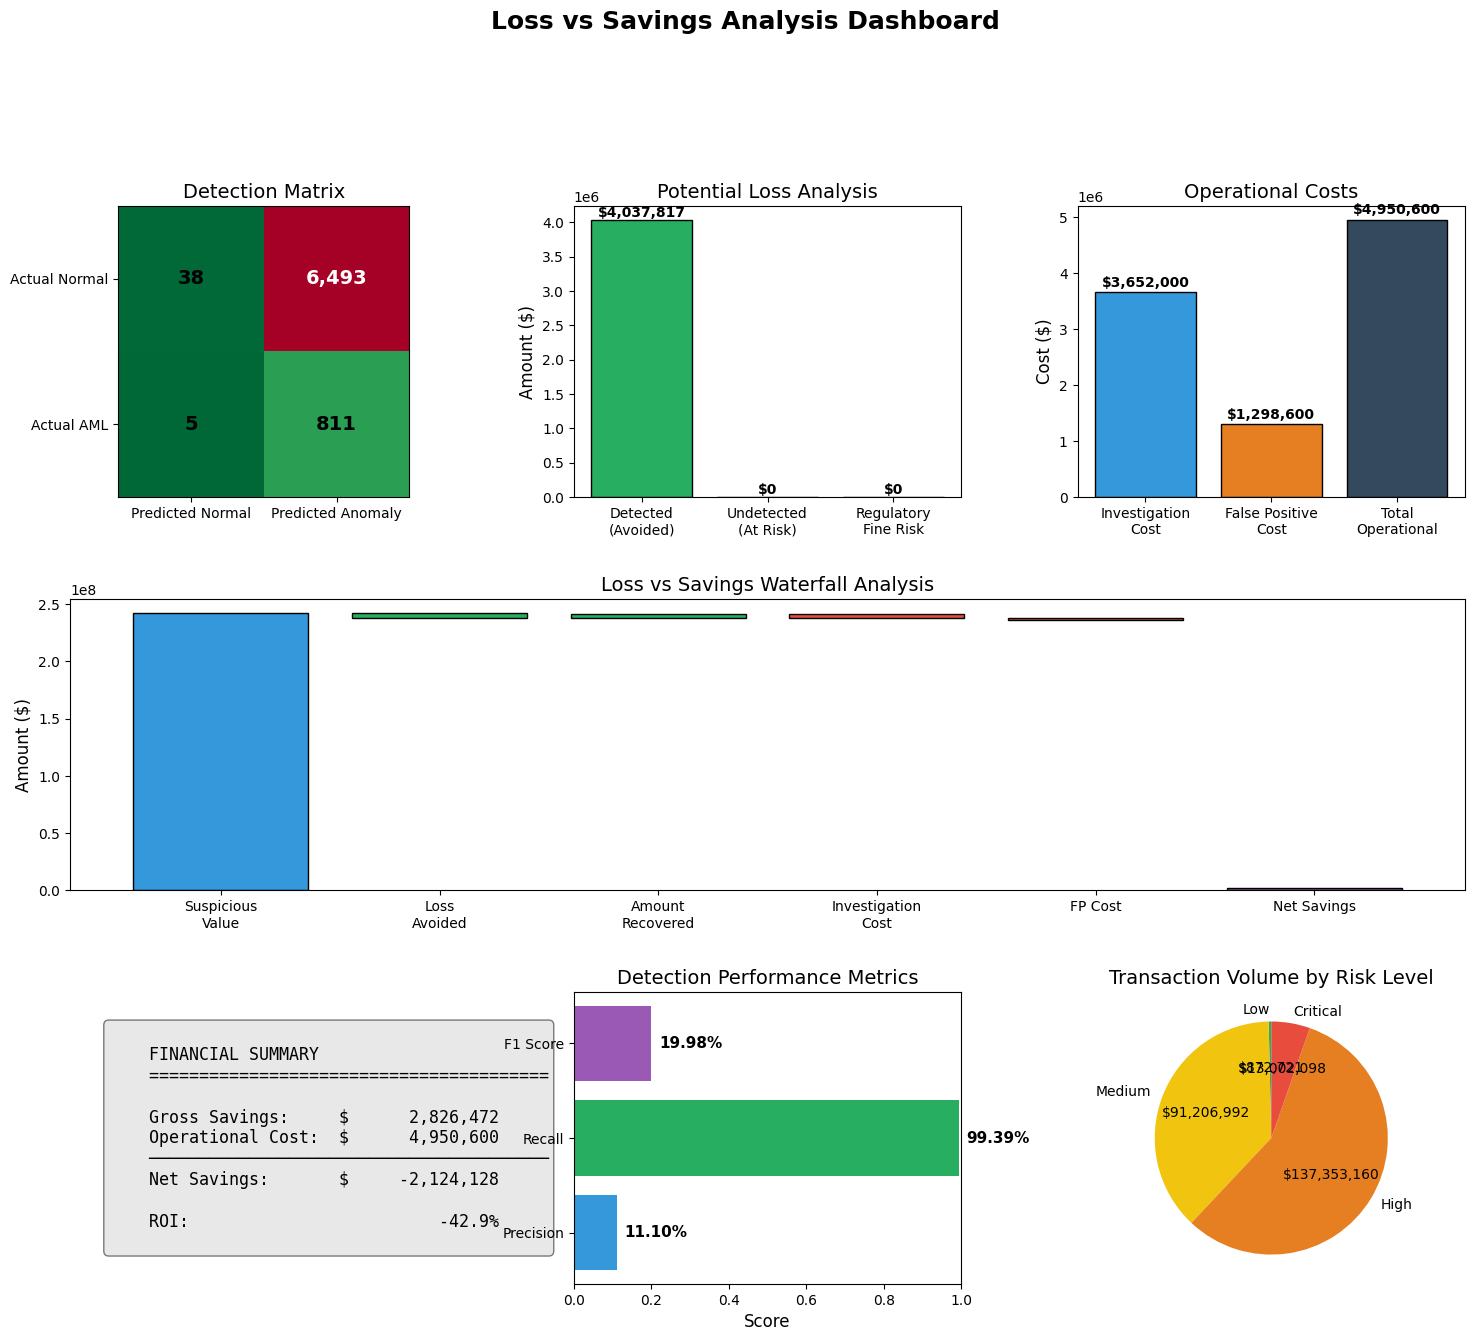

In [7]:
# Loss vs Savings Dashboard
def render_loss_savings_dashboard(ls):
    fig = plt.figure(figsize=(18, 14))
    gs = fig.add_gridspec(3, 3, hspace=0.35, wspace=0.3)
    
    # ========== Confusion Matrix Style Metrics (Top Left) ==========
    ax1 = fig.add_subplot(gs[0, 0])
    matrix_data = np.array([[ls['true_negatives'], ls['false_positives']], 
                           [ls['false_negatives'], ls['true_positives']]])
    im = ax1.imshow(matrix_data, cmap='RdYlGn_r')
    ax1.set_xticks([0, 1])
    ax1.set_yticks([0, 1])
    ax1.set_xticklabels(['Predicted Normal', 'Predicted Anomaly'])
    ax1.set_yticklabels(['Actual Normal', 'Actual AML'])
    ax1.set_title('Detection Matrix')
    
    for i in range(2):
        for j in range(2):
            text = ax1.text(j, i, f'{matrix_data[i, j]:,}', ha='center', va='center', 
                           fontsize=14, fontweight='bold', color='white' if matrix_data[i, j] > matrix_data.max()/2 else 'black')
    
    # ========== Loss Breakdown (Top Middle) ==========
    ax2 = fig.add_subplot(gs[0, 1])
    loss_categories = ['Detected\n(Avoided)', 'Undetected\n(At Risk)', 'Regulatory\nFine Risk']
    loss_values = [ls['potential_loss_detected'], ls['potential_loss_undetected'], ls['regulatory_fine_risk']]
    colors = ['#27ae60', '#e74c3c', '#8e44ad']
    
    bars = ax2.bar(loss_categories, loss_values, color=colors, edgecolor='black')
    ax2.set_ylabel('Amount ($)')
    ax2.set_title('Potential Loss Analysis')
    for bar, val in zip(bars, loss_values):
        ax2.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 5000, f'${val:,.0f}', 
                 ha='center', va='bottom', fontsize=10, fontweight='bold')
    
    # ========== Cost Breakdown (Top Right) ==========
    ax3 = fig.add_subplot(gs[0, 2])
    cost_labels = ['Investigation\nCost', 'False Positive\nCost', 'Total\nOperational']
    cost_values = [ls['investigation_cost'], ls['false_positive_cost'], ls['total_operational_cost']]
    colors = ['#3498db', '#e67e22', '#34495e']
    
    bars = ax3.bar(cost_labels, cost_values, color=colors, edgecolor='black')
    ax3.set_ylabel('Cost ($)')
    ax3.set_title('Operational Costs')
    for bar, val in zip(bars, cost_values):
        ax3.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 50000, f'${val:,.0f}', 
                 ha='center', va='bottom', fontsize=10, fontweight='bold')
    
    # ========== Savings Waterfall (Middle Row) ==========
    ax4 = fig.add_subplot(gs[1, :])
    
    waterfall_labels = ['Suspicious\nValue', 'Loss\nAvoided', 'Amount\nRecovered', 'Investigation\nCost', 'FP Cost', 'Net Savings']
    waterfall_values = [
        ls['suspicious_txn_value'],
        -ls['potential_loss_detected'],  # Reduction
        ls['recovered_amount'],
        -ls['investigation_cost'],
        -ls['false_positive_cost'],
        ls['net_savings']
    ]
    
    # Calculate cumulative for waterfall
    cumulative = [0]
    for i, v in enumerate(waterfall_values[:-1]):
        cumulative.append(cumulative[-1] + v)
    
    colors = ['#3498db', '#27ae60', '#27ae60', '#e74c3c', '#e74c3c', '#9b59b6']
    
    # Draw waterfall bars
    for i, (label, value, cum, color) in enumerate(zip(waterfall_labels, waterfall_values, cumulative, colors)):
        if i == 0 or i == len(waterfall_values) - 1:
            ax4.bar(i, abs(value), bottom=0, color=color, edgecolor='black')
        else:
            bottom = cum if value >= 0 else cum + value
            ax4.bar(i, abs(value), bottom=bottom, color=color, edgecolor='black')
    
    ax4.set_xticks(range(len(waterfall_labels)))
    ax4.set_xticklabels(waterfall_labels)
    ax4.set_ylabel('Amount ($)')
    ax4.set_title('Loss vs Savings Waterfall Analysis')
    ax4.axhline(y=0, color='black', linewidth=0.5)
    
    # ========== ROI Summary (Bottom Left) ==========
    ax5 = fig.add_subplot(gs[2, 0])
    ax5.axis('off')
    
    roi = (ls['net_savings'] / max(ls['total_operational_cost'], 1)) * 100
    
    summary_text = f"""
    FINANCIAL SUMMARY
    {'='*40}
    
    Gross Savings:     ${ls['gross_savings']:>15,.0f}
    Operational Cost:  ${ls['total_operational_cost']:>15,.0f}
    {'─'*40}
    Net Savings:       ${ls['net_savings']:>15,.0f}
    
    ROI:               {roi:>15.1f}%
    """
    ax5.text(0.1, 0.5, summary_text, fontsize=12, fontfamily='monospace', 
             verticalalignment='center', bbox=dict(boxstyle='round', facecolor='lightgray', alpha=0.5))
    
    # ========== Detection Performance (Bottom Middle) ==========
    ax6 = fig.add_subplot(gs[2, 1])
    
    precision = ls['true_positives'] / max(ls['true_positives'] + ls['false_positives'], 1)
    recall = ls['true_positives'] / max(ls['true_positives'] + ls['false_negatives'], 1)
    f1 = 2 * (precision * recall) / max(precision + recall, 0.0001)
    
    metrics = ['Precision', 'Recall', 'F1 Score']
    values = [precision, recall, f1]
    colors = ['#3498db', '#27ae60', '#9b59b6']
    
    bars = ax6.barh(metrics, values, color=colors)
    ax6.set_xlim(0, 1)
    ax6.set_xlabel('Score')
    ax6.set_title('Detection Performance Metrics')
    
    for bar, val in zip(bars, values):
        ax6.text(val + 0.02, bar.get_y() + bar.get_height()/2, f'{val:.2%}', 
                 va='center', fontsize=11, fontweight='bold')
    
    # ========== Risk-Adjusted Value (Bottom Right) ==========
    ax7 = fig.add_subplot(gs[2, 2])
    
    risk_bins = pd.cut(edges_df['edge_risk'], bins=[0, 0.25, 0.5, 0.75, 1.0], labels=['Low', 'Medium', 'High', 'Critical'])
    risk_volume = edges_df.groupby(risk_bins)['base_amt'].sum()
    
    colors = ['#27ae60', '#f1c40f', '#e67e22', '#e74c3c']
    wedges, texts, autotexts = ax7.pie(risk_volume.values, labels=risk_volume.index, colors=colors,
                                        autopct=lambda p: f'${p*risk_volume.sum()/100:,.0f}', startangle=90)
    ax7.set_title('Transaction Volume by Risk Level')
    
    plt.suptitle('Loss vs Savings Analysis Dashboard', fontsize=18, fontweight='bold', y=1.02)
    plt.tight_layout()
    plt.savefig(os.path.join(OUTPUT_PATH, 'dashboard_loss_savings.png'), dpi=150, bbox_inches='tight')
    plt.show()

render_loss_savings_dashboard(loss_savings)

---
# TAB 3: Risk-Weighted Network Visualization
---

Network visualization: 12 nodes, 10 edges


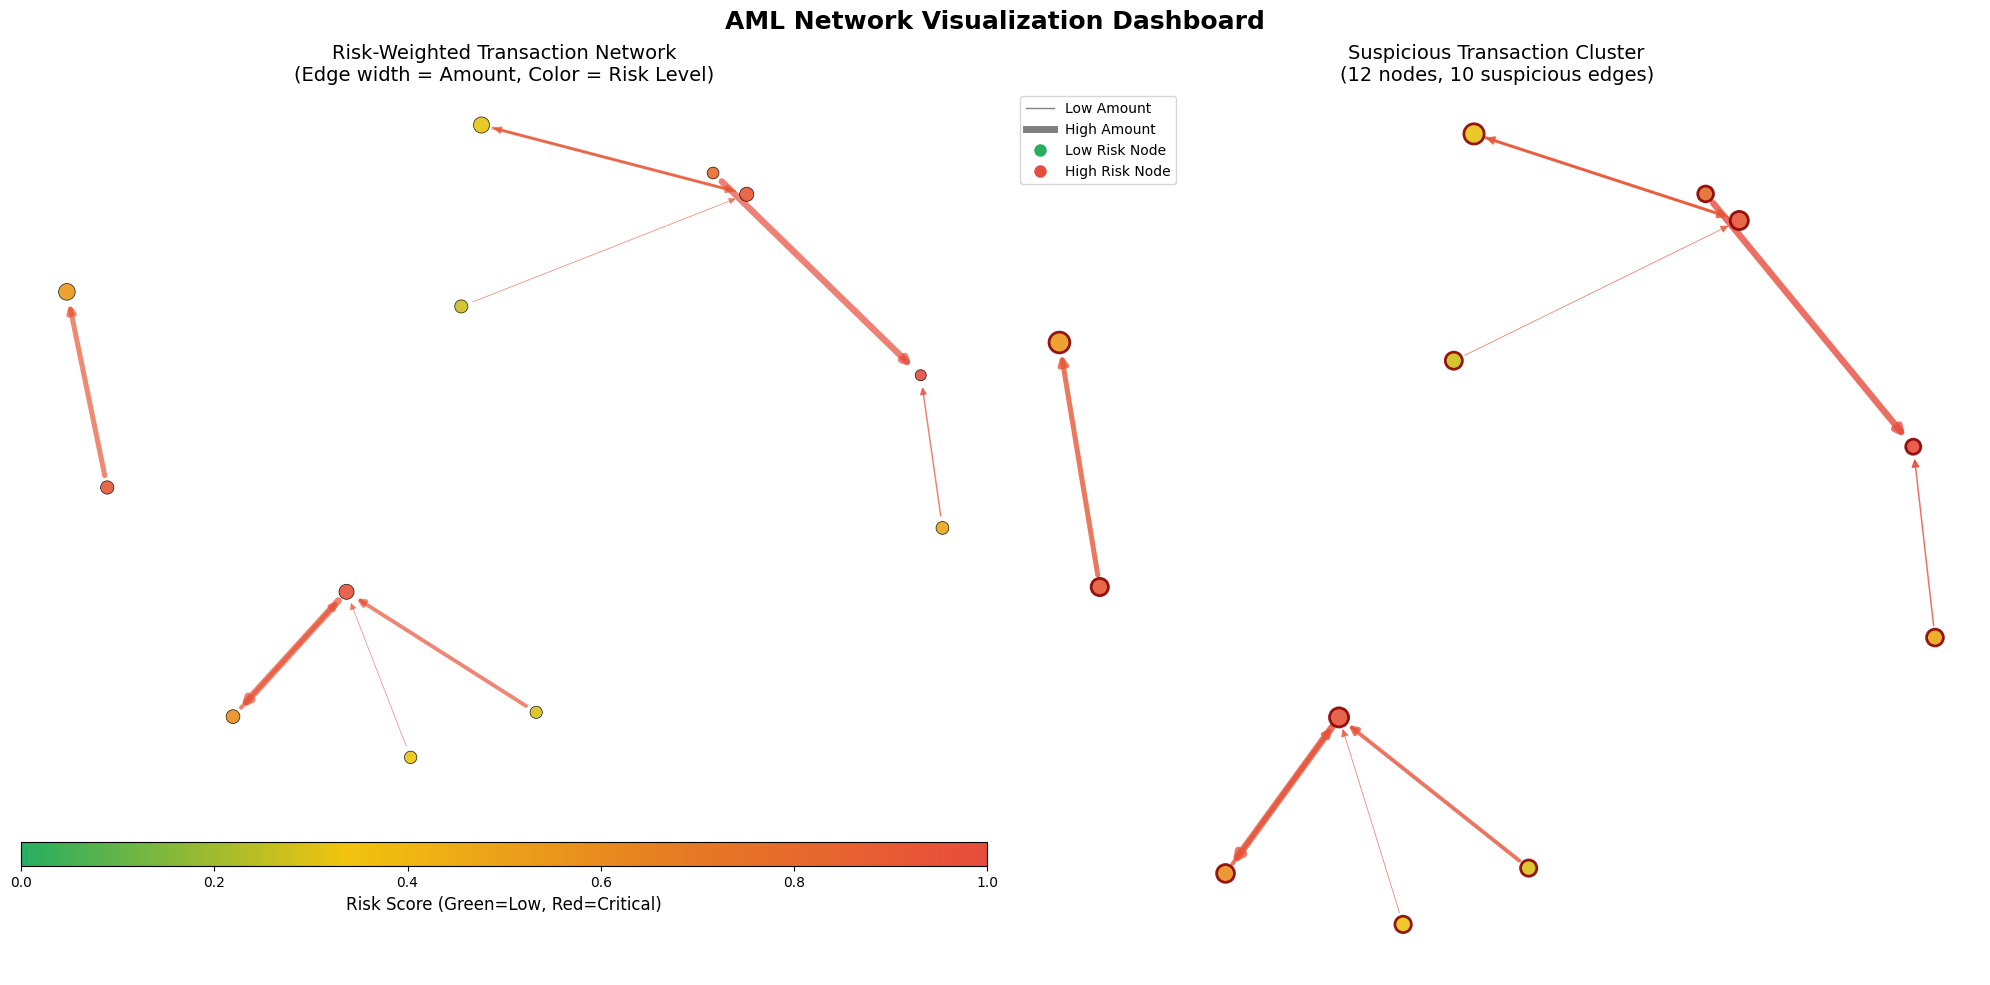

In [8]:
# Create risk-weighted color map for edges
def get_edge_color(risk_score):
    """Map risk score (0-1) to color: green -> yellow -> orange -> red"""
    cmap = LinearSegmentedColormap.from_list('risk', ['#27ae60', '#f1c40f', '#e67e22', '#e74c3c'])
    return cmap(risk_score)

def render_risk_network(max_nodes=300):
    """
    Render network with:
    - Edge WIDTH based on transaction AMOUNT
    - Edge COLOR based on AML RISK score
    """
    
    # Create graph with edge attributes
    G = nx.DiGraph()
    
    # Sample high-risk transactions for visualization
    # Prioritize high-risk, high-value transactions
    edges_sorted = edges_df.sort_values(['edge_risk', 'base_amt'], ascending=[False, False])
    
    # Get unique nodes from top transactions
    selected_edges = edges_sorted.head(max_nodes * 2)
    selected_nodes = set(selected_edges['source'].tolist() + selected_edges['target'].tolist())
    
    # Limit to max_nodes
    if len(selected_nodes) > max_nodes:
        # Keep highest risk nodes
        node_risks = node_embeddings[node_embeddings['id'].isin(selected_nodes)].nlargest(max_nodes, 'risk_score')['id'].tolist()
        selected_nodes = set(node_risks)
    
    # Build subgraph
    selected_edges_final = edges_df[
        (edges_df['source'].isin(selected_nodes)) & (edges_df['target'].isin(selected_nodes))
    ]
    
    for _, row in selected_edges_final.iterrows():
        G.add_edge(row['source'], row['target'], 
                   amount=row['base_amt'], 
                   risk=row['edge_risk'],
                   suspicious=row['is_suspicious'])
    
    print(f"Network visualization: {G.number_of_nodes()} nodes, {G.number_of_edges()} edges")
    
    # Create visualization
    fig, axes = plt.subplots(1, 2, figsize=(20, 10))
    
    # Layout
    pos = nx.spring_layout(G, k=3/np.sqrt(G.number_of_nodes()), iterations=50, seed=42)
    
    # ========== LEFT: Edge width = Amount, Edge color = Risk ==========
    ax1 = axes[0]
    
    # Normalize edge amounts for width
    amounts = [G[u][v]['amount'] for u, v in G.edges()]
    max_amt = max(amounts) if amounts else 1
    min_amt = min(amounts) if amounts else 0
    
    # Draw edges with variable width and color
    for u, v in G.edges():
        edge_data = G[u][v]
        # Width based on amount (1 to 5)
        width = 0.5 + 4.5 * (edge_data['amount'] - min_amt) / (max_amt - min_amt + 1)
        # Color based on risk
        color = get_edge_color(edge_data['risk'])
        
        nx.draw_networkx_edges(G, pos, edgelist=[(u, v)], width=width, 
                               edge_color=[color], alpha=0.7, 
                               arrows=True, arrowsize=10, ax=ax1)
    
    # Node colors and sizes
    node_colors = []
    node_sizes = []
    node_risk_dict = node_embeddings.set_index('id')['risk_score'].to_dict()
    node_volume_dict = node_money.set_index('id')['total_volume'].to_dict()
    max_vol = node_money['total_volume'].max()
    
    for node in G.nodes():
        risk = node_risk_dict.get(node, 0)
        vol = node_volume_dict.get(node, 0)
        
        node_colors.append(get_edge_color(risk))
        node_sizes.append(50 + 300 * (vol / max_vol))
    
    nx.draw_networkx_nodes(G, pos, node_color=node_colors, node_size=node_sizes, 
                           alpha=0.9, ax=ax1, edgecolors='black', linewidths=0.5)
    
    ax1.set_title('Risk-Weighted Transaction Network\n(Edge width = Amount, Color = Risk Level)', fontsize=14)
    ax1.axis('off')
    
    # Add colorbar for risk
    sm = ScalarMappable(cmap=LinearSegmentedColormap.from_list('risk', ['#27ae60', '#f1c40f', '#e67e22', '#e74c3c']),
                       norm=Normalize(vmin=0, vmax=1))
    sm.set_array([])
    cbar = plt.colorbar(sm, ax=ax1, orientation='horizontal', pad=0.05, aspect=40)
    cbar.set_label('Risk Score (Green=Low, Red=Critical)')
    
    # ========== RIGHT: Focus on Suspicious Cluster ==========
    ax2 = axes[1]
    
    # Filter to suspicious edges only
    suspicious_edges = [(u, v) for u, v in G.edges() if G[u][v]['suspicious']]
    
    if suspicious_edges:
        G_suspicious = G.edge_subgraph(suspicious_edges).copy()
        pos_suspicious = {n: pos[n] for n in G_suspicious.nodes() if n in pos}
        
        # Draw suspicious subnetwork
        for u, v in G_suspicious.edges():
            edge_data = G_suspicious[u][v]
            width = 0.5 + 4.5 * (edge_data['amount'] - min_amt) / (max_amt - min_amt + 1)
            color = get_edge_color(edge_data['risk'])
            
            nx.draw_networkx_edges(G_suspicious, pos_suspicious, edgelist=[(u, v)], 
                                   width=width, edge_color=[color], alpha=0.8,
                                   arrows=True, arrowsize=12, ax=ax2)
        
        susp_colors = [get_edge_color(node_risk_dict.get(n, 0)) for n in G_suspicious.nodes()]
        susp_sizes = [100 + 400 * (node_volume_dict.get(n, 0) / max_vol) for n in G_suspicious.nodes()]
        
        nx.draw_networkx_nodes(G_suspicious, pos_suspicious, node_color=susp_colors, 
                               node_size=susp_sizes, alpha=0.9, ax=ax2,
                               edgecolors='darkred', linewidths=2)
        
        ax2.set_title(f'Suspicious Transaction Cluster\n({G_suspicious.number_of_nodes()} nodes, {G_suspicious.number_of_edges()} suspicious edges)', fontsize=14)
    else:
        ax2.text(0.5, 0.5, 'No suspicious edges in sample', ha='center', va='center', fontsize=14)
        ax2.set_title('Suspicious Transaction Cluster')
    
    ax2.axis('off')
    
    # Add legend
    legend_elements = [
        Line2D([0], [0], color='gray', linewidth=1, label='Low Amount'),
        Line2D([0], [0], color='gray', linewidth=5, label='High Amount'),
        Line2D([0], [0], marker='o', color='w', markerfacecolor='#27ae60', markersize=10, label='Low Risk Node'),
        Line2D([0], [0], marker='o', color='w', markerfacecolor='#e74c3c', markersize=10, label='High Risk Node'),
    ]
    ax2.legend(handles=legend_elements, loc='upper left')
    
    plt.suptitle('AML Network Visualization Dashboard', fontsize=18, fontweight='bold')
    plt.tight_layout()
    plt.savefig(os.path.join(OUTPUT_PATH, 'dashboard_risk_network.png'), dpi=150, bbox_inches='tight')
    plt.show()

render_risk_network(max_nodes=200)

---
# TAB 4: Transaction Deep Dive
---

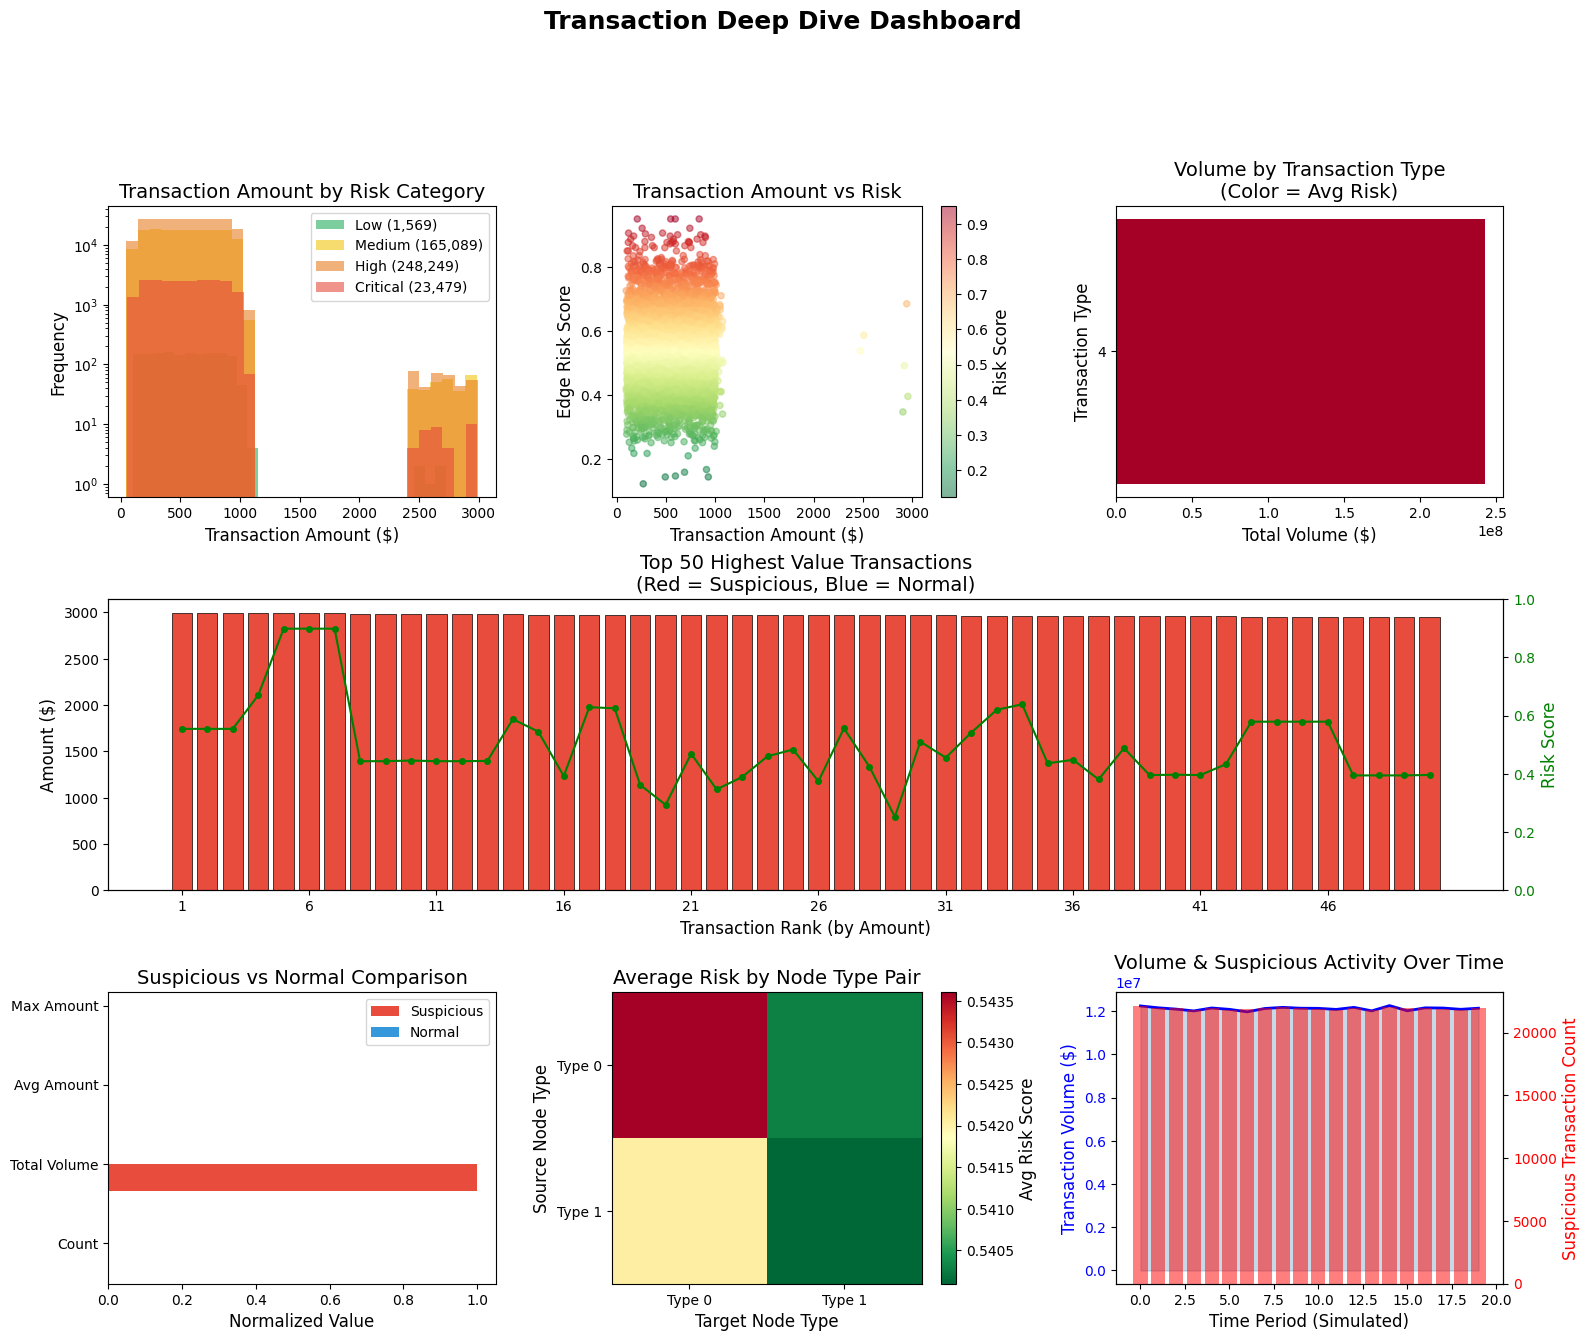

In [9]:
def render_transaction_deepdive():
    fig = plt.figure(figsize=(18, 14))
    gs = fig.add_gridspec(3, 3, hspace=0.35, wspace=0.3)
    
    # ========== Transaction Amount Distribution by Risk (Top Left) ==========
    ax1 = fig.add_subplot(gs[0, 0])
    
    risk_categories = pd.cut(edges_df['edge_risk'], bins=[0, 0.25, 0.5, 0.75, 1.0], 
                             labels=['Low', 'Medium', 'High', 'Critical'])
    
    for cat, color in zip(['Low', 'Medium', 'High', 'Critical'], ['#27ae60', '#f1c40f', '#e67e22', '#e74c3c']):
        data = edges_df[risk_categories == cat]['base_amt']
        if len(data) > 0:
            ax1.hist(data, bins=30, alpha=0.6, label=f'{cat} ({len(data):,})', color=color)
    
    ax1.set_xlabel('Transaction Amount ($)')
    ax1.set_ylabel('Frequency')
    ax1.set_title('Transaction Amount by Risk Category')
    ax1.legend()
    ax1.set_yscale('log')
    
    # ========== Amount vs Risk Scatter (Top Middle) ==========
    ax2 = fig.add_subplot(gs[0, 1])
    
    sample = edges_df.sample(min(5000, len(edges_df)), random_state=42)
    scatter = ax2.scatter(sample['base_amt'], sample['edge_risk'], 
                          c=sample['edge_risk'], cmap='RdYlGn_r', 
                          alpha=0.5, s=20)
    ax2.set_xlabel('Transaction Amount ($)')
    ax2.set_ylabel('Edge Risk Score')
    ax2.set_title('Transaction Amount vs Risk')
    plt.colorbar(scatter, ax=ax2, label='Risk Score')
    
    # ========== Transaction Type Analysis (Top Right) ==========
    ax3 = fig.add_subplot(gs[0, 2])
    
    type_stats = edges_df.groupby('tx_type').agg({
        'base_amt': ['sum', 'mean', 'count'],
        'edge_risk': 'mean'
    }).round(2)
    type_stats.columns = ['Total Vol', 'Avg Amt', 'Count', 'Avg Risk']
    type_stats = type_stats.sort_values('Avg Risk', ascending=False)
    
    colors = plt.cm.RdYlGn_r(type_stats['Avg Risk'] / type_stats['Avg Risk'].max())
    bars = ax3.barh(type_stats.index.astype(str), type_stats['Total Vol'], color=colors)
    ax3.set_xlabel('Total Volume ($)')
    ax3.set_ylabel('Transaction Type')
    ax3.set_title('Volume by Transaction Type\n(Color = Avg Risk)')
    
    # ========== High Value Transaction Analysis (Middle Row) ==========
    ax4 = fig.add_subplot(gs[1, :])
    
    # Top 50 highest value transactions
    top_txns = edges_df.nlargest(50, 'base_amt')[['source', 'target', 'base_amt', 'edge_risk', 'is_suspicious']]
    
    x = range(len(top_txns))
    colors = ['#e74c3c' if s else '#3498db' for s in top_txns['is_suspicious']]
    bars = ax4.bar(x, top_txns['base_amt'], color=colors, edgecolor='black', linewidth=0.5)
    
    # Add risk indicator on top
    ax4_twin = ax4.twinx()
    ax4_twin.plot(x, top_txns['edge_risk'], 'go-', markersize=4, linewidth=1.5, label='Risk Score')
    ax4_twin.set_ylabel('Risk Score', color='green')
    ax4_twin.tick_params(axis='y', labelcolor='green')
    ax4_twin.set_ylim(0, 1)
    
    ax4.set_xlabel('Transaction Rank (by Amount)')
    ax4.set_ylabel('Amount ($)')
    ax4.set_title('Top 50 Highest Value Transactions\n(Red = Suspicious, Blue = Normal)')
    ax4.set_xticks(x[::5])
    ax4.set_xticklabels([str(i+1) for i in x[::5]])
    
    # ========== Suspicious vs Normal Stats (Bottom Left) ==========
    ax5 = fig.add_subplot(gs[2, 0])
    
    stats_comparison = pd.DataFrame({
        'Metric': ['Count', 'Total Volume', 'Avg Amount', 'Max Amount'],
        'Suspicious': [
            edges_df['is_suspicious'].sum(),
            edges_df[edges_df['is_suspicious']]['base_amt'].sum(),
            edges_df[edges_df['is_suspicious']]['base_amt'].mean(),
            edges_df[edges_df['is_suspicious']]['base_amt'].max()
        ],
        'Normal': [
            (~edges_df['is_suspicious']).sum(),
            edges_df[~edges_df['is_suspicious']]['base_amt'].sum(),
            edges_df[~edges_df['is_suspicious']]['base_amt'].mean(),
            edges_df[~edges_df['is_suspicious']]['base_amt'].max()
        ]
    })
    
    x_pos = np.arange(len(stats_comparison))
    width = 0.35
    
    # Normalize for visualization
    susp_norm = stats_comparison['Suspicious'] / stats_comparison['Suspicious'].max()
    norm_norm = stats_comparison['Normal'] / stats_comparison['Normal'].max()
    
    ax5.barh(x_pos - width/2, susp_norm, width, label='Suspicious', color='#e74c3c')
    ax5.barh(x_pos + width/2, norm_norm, width, label='Normal', color='#3498db')
    ax5.set_yticks(x_pos)
    ax5.set_yticklabels(stats_comparison['Metric'])
    ax5.set_xlabel('Normalized Value')
    ax5.set_title('Suspicious vs Normal Comparison')
    ax5.legend()
    
    # ========== Risk Heatmap by Source-Target Type (Bottom Middle) ==========
    ax6 = fig.add_subplot(gs[2, 1])
    
    # Get node types
    node_type_dict = nodes_df.set_index('id')['type'].to_dict()
    edges_df['source_type'] = edges_df['source'].map(node_type_dict).fillna(-1).astype(int)
    edges_df['target_type'] = edges_df['target'].map(node_type_dict).fillna(-1).astype(int)
    
    heatmap_data = edges_df.pivot_table(values='edge_risk', index='source_type', 
                                         columns='target_type', aggfunc='mean').fillna(0)
    
    im = ax6.imshow(heatmap_data.values, cmap='RdYlGn_r', aspect='auto')
    ax6.set_xticks(range(len(heatmap_data.columns)))
    ax6.set_yticks(range(len(heatmap_data.index)))
    ax6.set_xticklabels([f'Type {c}' for c in heatmap_data.columns])
    ax6.set_yticklabels([f'Type {i}' for i in heatmap_data.index])
    ax6.set_xlabel('Target Node Type')
    ax6.set_ylabel('Source Node Type')
    ax6.set_title('Average Risk by Node Type Pair')
    plt.colorbar(im, ax=ax6, label='Avg Risk Score')
    
    # ========== Transaction Volume Time Series Simulation (Bottom Right) ==========
    ax7 = fig.add_subplot(gs[2, 2])
    
    # Simulate time-based aggregation using transaction IDs as proxy
    edges_df['time_bucket'] = pd.cut(edges_df['tran_id'], bins=20, labels=range(20))
    time_agg = edges_df.groupby('time_bucket').agg({
        'base_amt': 'sum',
        'is_suspicious': 'sum',
        'edge_risk': 'mean'
    })
    
    ax7.fill_between(range(len(time_agg)), time_agg['base_amt'], alpha=0.3, color='steelblue')
    ax7.plot(range(len(time_agg)), time_agg['base_amt'], 'b-', linewidth=2, label='Total Volume')
    
    ax7_twin = ax7.twinx()
    ax7_twin.bar(range(len(time_agg)), time_agg['is_suspicious'], alpha=0.5, color='red', label='Suspicious Count')
    ax7_twin.set_ylabel('Suspicious Transaction Count', color='red')
    ax7_twin.tick_params(axis='y', labelcolor='red')
    
    ax7.set_xlabel('Time Period (Simulated)')
    ax7.set_ylabel('Transaction Volume ($)', color='blue')
    ax7.tick_params(axis='y', labelcolor='blue')
    ax7.set_title('Volume & Suspicious Activity Over Time')
    
    plt.suptitle('Transaction Deep Dive Dashboard', fontsize=18, fontweight='bold', y=1.02)
    plt.tight_layout()
    plt.savefig(os.path.join(OUTPUT_PATH, 'dashboard_transaction_deepdive.png'), dpi=150, bbox_inches='tight')
    plt.show()

render_transaction_deepdive()

---
# TAB 5: Node Risk Profiles
---

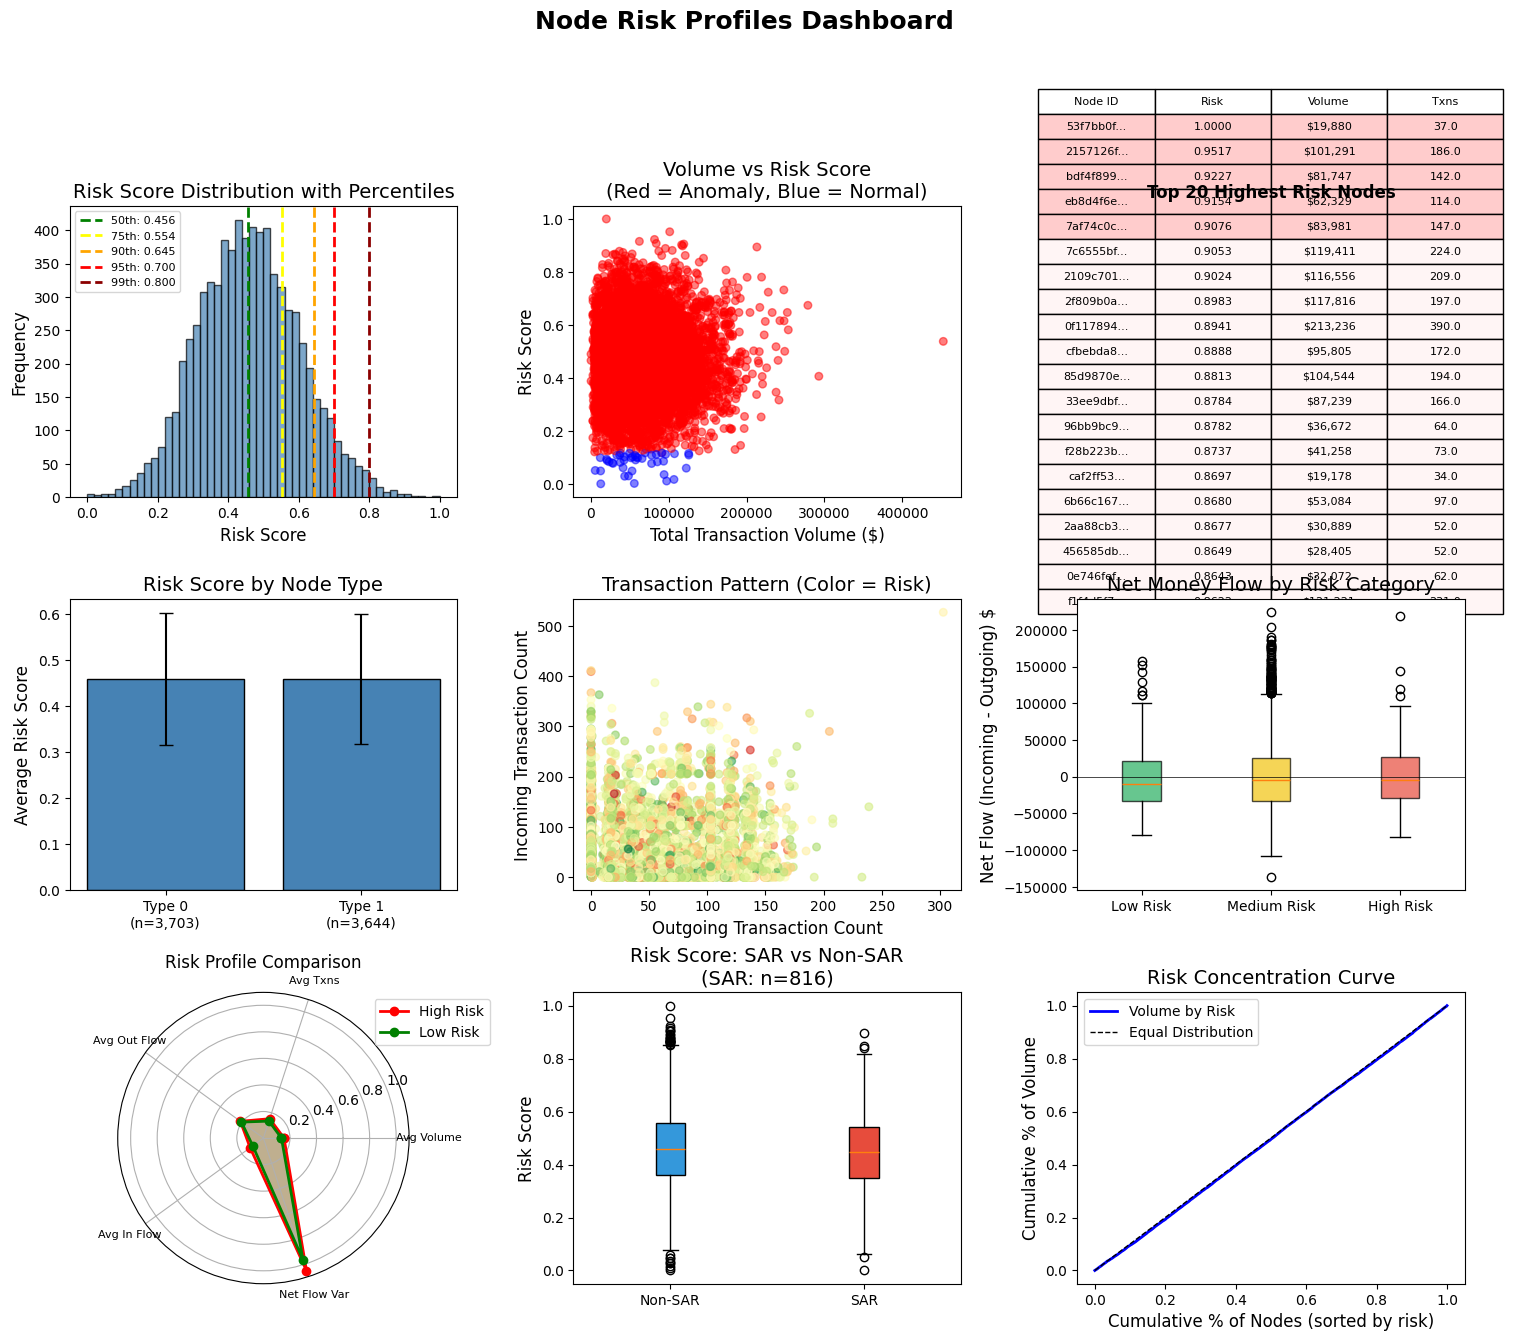

In [10]:
def render_node_risk_profiles():
    fig = plt.figure(figsize=(18, 14))
    gs = fig.add_gridspec(3, 3, hspace=0.35, wspace=0.3)
    
    # ========== Risk Score Distribution (Top Left) ==========
    ax1 = fig.add_subplot(gs[0, 0])
    
    ax1.hist(node_money['risk_score'], bins=50, color='steelblue', edgecolor='black', alpha=0.7)
    percentiles = [50, 75, 90, 95, 99]
    colors = ['green', 'yellow', 'orange', 'red', 'darkred']
    for p, c in zip(percentiles, colors):
        val = np.percentile(node_money['risk_score'], p)
        ax1.axvline(x=val, color=c, linestyle='--', linewidth=2, label=f'{p}th: {val:.3f}')
    
    ax1.set_xlabel('Risk Score')
    ax1.set_ylabel('Frequency')
    ax1.set_title('Risk Score Distribution with Percentiles')
    ax1.legend(fontsize=8)
    
    # ========== Risk vs Volume Scatter (Top Middle) ==========
    ax2 = fig.add_subplot(gs[0, 1])
    
    scatter = ax2.scatter(node_money['total_volume'], node_money['risk_score'],
                          c=node_money['is_anomaly'].map({True: 'red', False: 'blue'}),
                          alpha=0.5, s=30)
    ax2.set_xlabel('Total Transaction Volume ($)')
    ax2.set_ylabel('Risk Score')
    ax2.set_title('Volume vs Risk Score\n(Red = Anomaly, Blue = Normal)')
    
    # ========== Top 20 High Risk Nodes Table (Top Right) ==========
    ax3 = fig.add_subplot(gs[0, 2])
    ax3.axis('off')
    
    top20 = node_money.nlargest(20, 'risk_score')[['id', 'risk_score', 'total_volume', 'total_transactions']]
    top20['id'] = top20['id'].str[:12] + '...'
    top20['total_volume'] = top20['total_volume'].apply(lambda x: f'${x:,.0f}')
    top20['risk_score'] = top20['risk_score'].apply(lambda x: f'{x:.4f}')
    
    table = ax3.table(cellText=top20.values, colLabels=['Node ID', 'Risk', 'Volume', 'Txns'],
                      loc='center', cellLoc='center')
    table.auto_set_font_size(False)
    table.set_fontsize(8)
    table.scale(1.2, 1.5)
    
    # Color high risk rows
    for i in range(len(top20)):
        for j in range(4):
            cell = table[(i+1, j)]
            cell.set_facecolor('#ffcccc' if i < 5 else '#fff5f5')
    
    ax3.set_title('Top 20 Highest Risk Nodes', fontsize=12, fontweight='bold')
    
    # ========== Node Type Risk Comparison (Middle Left) ==========
    ax4 = fig.add_subplot(gs[1, 0])
    
    node_money_typed = node_money.merge(nodes_df[['id', 'type']], on='id', how='left')
    type_risk = node_money_typed.groupby('type')['risk_score'].agg(['mean', 'std', 'count'])
    
    x = range(len(type_risk))
    ax4.bar(x, type_risk['mean'], yerr=type_risk['std'], capsize=5, color='steelblue', edgecolor='black')
    ax4.set_xticks(x)
    ax4.set_xticklabels([f'Type {t}\n(n={c:,})' for t, c in zip(type_risk.index, type_risk['count'])])
    ax4.set_ylabel('Average Risk Score')
    ax4.set_title('Risk Score by Node Type')
    
    # ========== In/Out Degree vs Risk (Middle Center) ==========
    ax5 = fig.add_subplot(gs[1, 1])
    
    ax5.scatter(node_money['outgoing_count'], node_money['incoming_count'],
                c=node_money['risk_score'], cmap='RdYlGn_r', alpha=0.6, s=30)
    ax5.set_xlabel('Outgoing Transaction Count')
    ax5.set_ylabel('Incoming Transaction Count')
    ax5.set_title('Transaction Pattern (Color = Risk)')
    
    # ========== Net Flow Analysis (Middle Right) ==========
    ax6 = fig.add_subplot(gs[1, 2])
    
    node_money['net_flow'] = node_money['incoming_amt'] - node_money['outgoing_amt']
    
    # Classify nodes
    high_risk = node_money[node_money['risk_score'] > 0.75]
    med_risk = node_money[(node_money['risk_score'] > 0.25) & (node_money['risk_score'] <= 0.75)]
    low_risk = node_money[node_money['risk_score'] <= 0.25]
    
    data = [low_risk['net_flow'], med_risk['net_flow'], high_risk['net_flow']]
    bp = ax6.boxplot(data, labels=['Low Risk', 'Medium Risk', 'High Risk'], patch_artist=True)
    
    for patch, color in zip(bp['boxes'], ['#27ae60', '#f1c40f', '#e74c3c']):
        patch.set_facecolor(color)
        patch.set_alpha(0.7)
    
    ax6.set_ylabel('Net Flow (Incoming - Outgoing) $')
    ax6.set_title('Net Money Flow by Risk Category')
    ax6.axhline(y=0, color='black', linestyle='-', linewidth=0.5)
    
    # ========== Risk Profile Radar Chart (Bottom Left) ==========
    ax7 = fig.add_subplot(gs[2, 0], projection='polar')
    
    # Calculate metrics for high risk vs low risk nodes
    categories = ['Avg Volume', 'Avg Txns', 'Avg Out Flow', 'Avg In Flow', 'Net Flow Var']
    
    high_metrics = [
        high_risk['total_volume'].mean() / node_money['total_volume'].max(),
        high_risk['total_transactions'].mean() / node_money['total_transactions'].max(),
        high_risk['outgoing_amt'].mean() / node_money['outgoing_amt'].max(),
        high_risk['incoming_amt'].mean() / node_money['incoming_amt'].max(),
        high_risk['net_flow'].std() / node_money['net_flow'].std() if node_money['net_flow'].std() > 0 else 0
    ]
    
    low_metrics = [
        low_risk['total_volume'].mean() / node_money['total_volume'].max() if len(low_risk) > 0 else 0,
        low_risk['total_transactions'].mean() / node_money['total_transactions'].max() if len(low_risk) > 0 else 0,
        low_risk['outgoing_amt'].mean() / node_money['outgoing_amt'].max() if len(low_risk) > 0 else 0,
        low_risk['incoming_amt'].mean() / node_money['incoming_amt'].max() if len(low_risk) > 0 else 0,
        low_risk['net_flow'].std() / node_money['net_flow'].std() if len(low_risk) > 0 and node_money['net_flow'].std() > 0 else 0
    ]
    
    angles = np.linspace(0, 2 * np.pi, len(categories), endpoint=False).tolist()
    high_metrics += high_metrics[:1]
    low_metrics += low_metrics[:1]
    angles += angles[:1]
    
    ax7.plot(angles, high_metrics, 'o-', linewidth=2, label='High Risk', color='red')
    ax7.fill(angles, high_metrics, alpha=0.25, color='red')
    ax7.plot(angles, low_metrics, 'o-', linewidth=2, label='Low Risk', color='green')
    ax7.fill(angles, low_metrics, alpha=0.25, color='green')
    
    ax7.set_xticks(angles[:-1])
    ax7.set_xticklabels(categories, size=8)
    ax7.set_title('Risk Profile Comparison', size=12)
    ax7.legend(loc='upper right', bbox_to_anchor=(1.3, 1.0))
    
    # ========== SAR Analysis (Bottom Middle) - if available ==========
    ax8 = fig.add_subplot(gs[2, 1])
    
    if 'is_sar' in node_money.columns:
        sar_nodes = node_money[node_money['is_sar'] == 1]
        non_sar = node_money[node_money['is_sar'] == 0]
        
        # Risk score comparison
        bp = ax8.boxplot([non_sar['risk_score'], sar_nodes['risk_score']], 
                         labels=['Non-SAR', 'SAR'], patch_artist=True)
        bp['boxes'][0].set_facecolor('#3498db')
        bp['boxes'][1].set_facecolor('#e74c3c')
        
        ax8.set_ylabel('Risk Score')
        ax8.set_title(f'Risk Score: SAR vs Non-SAR\n(SAR: n={len(sar_nodes):,})')
    else:
        # Show anomaly detection performance
        detected = node_money['is_anomaly'].sum()
        not_detected = len(node_money) - detected
        ax8.pie([detected, not_detected], labels=['Detected', 'Not Detected'],
                colors=['#e74c3c', '#3498db'], autopct='%1.1f%%', startangle=90)
        ax8.set_title('Anomaly Detection Results')
    
    # ========== Risk Concentration (Bottom Right) ==========
    ax9 = fig.add_subplot(gs[2, 2])
    
    # Lorenz curve for risk concentration
    sorted_volume = node_money.sort_values('risk_score')['total_volume'].cumsum() / node_money['total_volume'].sum()
    x_lorenz = np.linspace(0, 1, len(sorted_volume))
    
    ax9.plot(x_lorenz, sorted_volume.values, 'b-', linewidth=2, label='Volume by Risk')
    ax9.plot([0, 1], [0, 1], 'k--', linewidth=1, label='Equal Distribution')
    ax9.fill_between(x_lorenz, sorted_volume.values, x_lorenz, alpha=0.3, color='blue')
    
    ax9.set_xlabel('Cumulative % of Nodes (sorted by risk)')
    ax9.set_ylabel('Cumulative % of Volume')
    ax9.set_title('Risk Concentration Curve')
    ax9.legend()
    
    plt.suptitle('Node Risk Profiles Dashboard', fontsize=18, fontweight='bold', y=1.02)
    plt.tight_layout()
    plt.savefig(os.path.join(OUTPUT_PATH, 'dashboard_node_profiles.png'), dpi=150, bbox_inches='tight')
    plt.show()

render_node_risk_profiles()

---
# Interactive Tab Navigation (if widgets available)
---

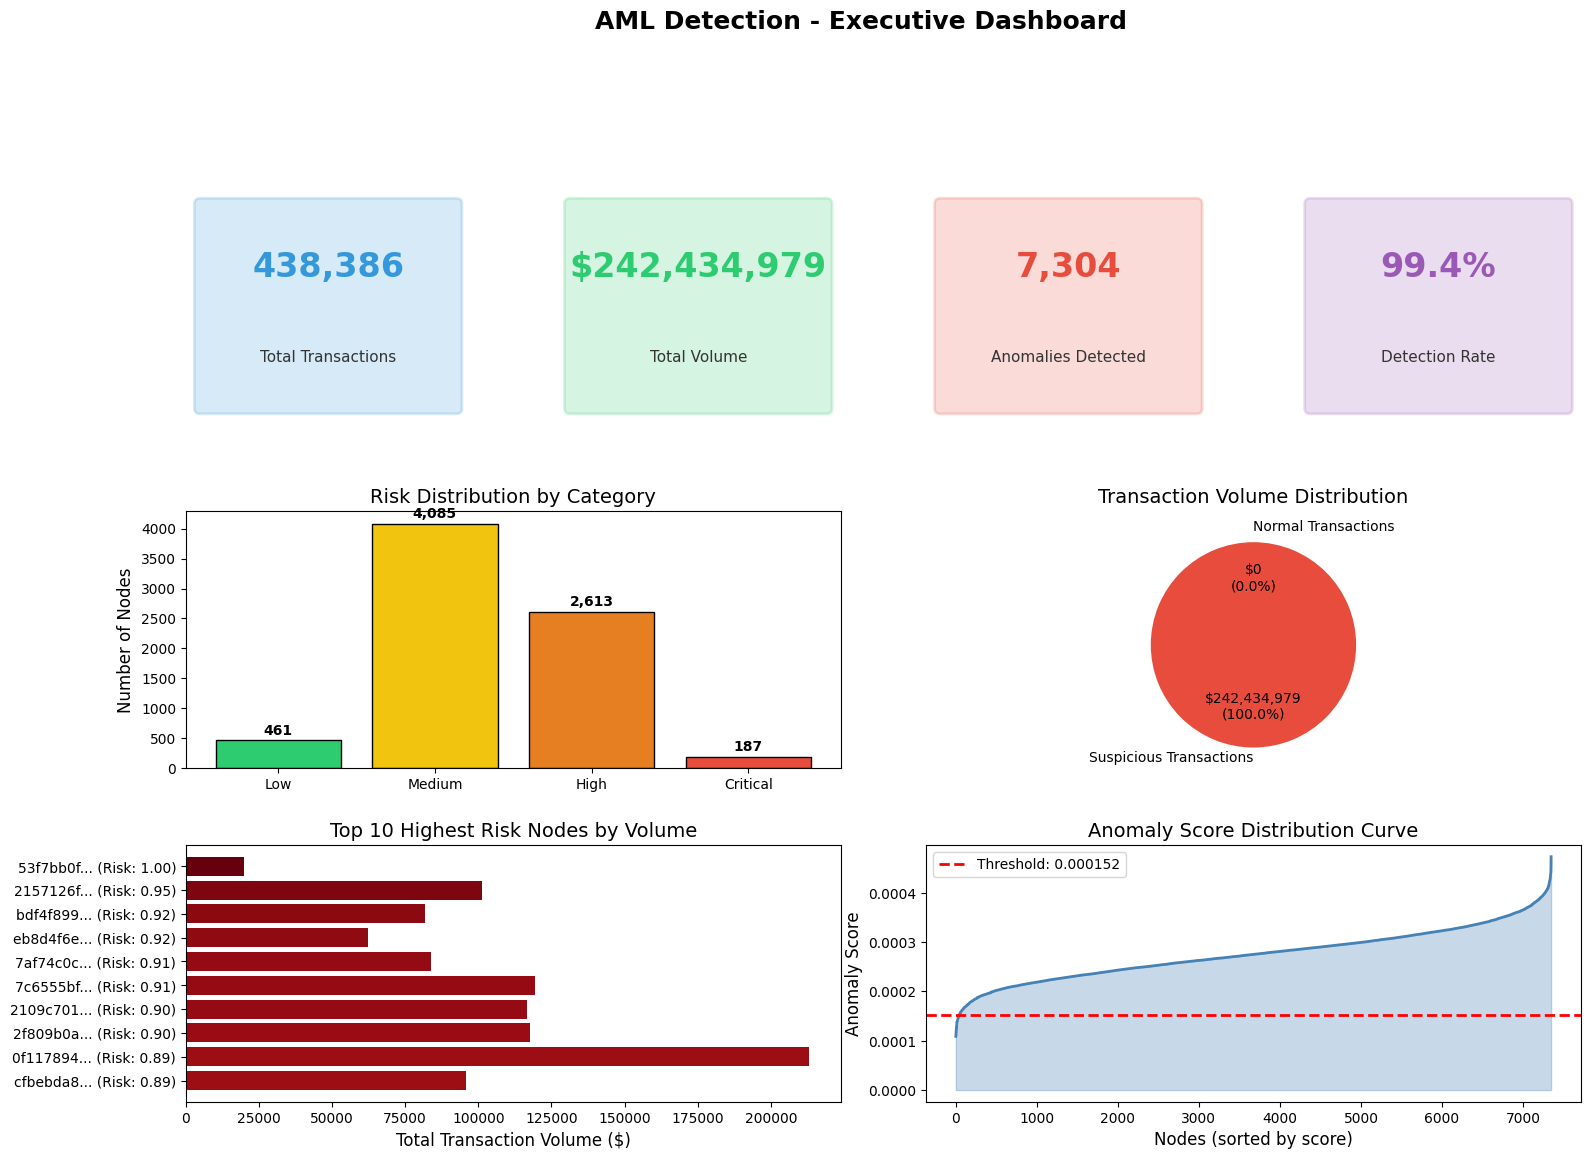

In [11]:
if HAS_WIDGETS:
    # Create interactive tabs
    tab_contents = ['Executive Summary', 'Loss vs Savings', 'Risk Network', 'Transaction Deep Dive', 'Node Profiles']
    tab_functions = [
        render_executive_summary,
        lambda: render_loss_savings_dashboard(loss_savings),
        lambda: render_risk_network(max_nodes=200),
        render_transaction_deepdive,
        render_node_risk_profiles
    ]
    
    def on_tab_change(change):
        clear_output(wait=True)
        display(tab_widget)
        tab_functions[change['new']]()
    
    tab_widget = widgets.Tab()
    tab_widget.children = [widgets.Output() for _ in tab_contents]
    for i, title in enumerate(tab_contents):
        tab_widget.set_title(i, title)
    
    tab_widget.observe(on_tab_change, names='selected_index')
    
    display(HTML('<h2>Interactive AML Dashboard</h2>'))
    display(HTML('<p>Select a tab below to view different analysis perspectives:</p>'))
    display(tab_widget)
    
    # Show first tab by default
    render_executive_summary()
else:
    print("Interactive widgets not available. All dashboard tabs have been rendered above.")

---
# Dashboard Summary Report
---

In [12]:
# Final Dashboard Summary
print("\n" + "="*80)
print(" AML ANALYTICAL DASHBOARD - SUMMARY REPORT ")
print("="*80)

print(f"\n{'DATASET OVERVIEW':^40}")
print("-"*40)
print(f"  Total Nodes:              {len(node_embeddings):>12,}")
print(f"  Total Transactions:       {len(edges_df):>12,}")
print(f"  Total Value:              ${edges_df['base_amt'].sum():>11,.0f}")

print(f"\n{'DETECTION RESULTS':^40}")
print("-"*40)
print(f"  Anomalies Detected:       {node_embeddings['is_anomaly'].sum():>12,}")
print(f"  Detection Rate:           {100*node_embeddings['is_anomaly'].mean():>11.1f}%")
print(f"  Suspicious Transactions:  {edges_df['is_suspicious'].sum():>12,}")

print(f"\n{'FINANCIAL IMPACT':^40}")
print("-"*40)
ls = loss_savings
print(f"  Suspicious Volume:        ${ls['suspicious_txn_value']:>11,.0f}")
print(f"  Potential Loss Avoided:   ${ls['potential_loss_detected']:>11,.0f}")
print(f"  Amount Recovered:         ${ls['recovered_amount']:>11,.0f}")
print(f"  Operational Cost:         ${ls['total_operational_cost']:>11,.0f}")
print(f"  Net Savings:              ${ls['net_savings']:>11,.0f}")

print(f"\n{'OUTPUT FILES GENERATED':^40}")
print("-"*40)
output_files = [
    'dashboard_executive.png',
    'dashboard_loss_savings.png', 
    'dashboard_risk_network.png',
    'dashboard_transaction_deepdive.png',
    'dashboard_node_profiles.png'
]
for f in output_files:
    print(f"  - {f}")

print("\n" + "="*80)
print(" DASHBOARD COMPLETE ")
print("="*80)


 AML ANALYTICAL DASHBOARD - SUMMARY REPORT 

            DATASET OVERVIEW            
----------------------------------------
  Total Nodes:                     7,347
  Total Transactions:            438,386
  Total Value:              $242,434,979

           DETECTION RESULTS            
----------------------------------------
  Anomalies Detected:              7,304
  Detection Rate:                  99.4%
  Suspicious Transactions:       438,386

            FINANCIAL IMPACT            
----------------------------------------
  Suspicious Volume:        $242,434,979
  Potential Loss Avoided:   $  4,037,817
  Amount Recovered:         $  2,826,472
  Operational Cost:         $  4,950,600
  Net Savings:              $ -2,124,128

         OUTPUT FILES GENERATED         
----------------------------------------
  - dashboard_executive.png
  - dashboard_loss_savings.png
  - dashboard_risk_network.png
  - dashboard_transaction_deepdive.png
  - dashboard_node_profiles.png

 DASHBOARD